In [1]:
import numpy as np

def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)   # + noise
    return series[..., np.newaxis].astype(np.float32)

In [2]:
n_steps = 50
series = generate_time_series(10000, n_steps + 1)
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]
X_train.shape, y_train.shape

((7000, 50, 1), (7000, 1))

In [3]:
print (series)

[[[-0.26963443]
  [-0.3108438 ]
  [-0.4012016 ]
  ...
  [ 0.51064783]
  [ 0.31399897]
  [ 0.07817329]]

 [[ 0.4537679 ]
  [ 0.38872716]
  [ 0.1945055 ]
  ...
  [-0.05409752]
  [ 0.2156161 ]
  [ 0.53156537]]

 [[ 0.23929167]
  [ 0.28412843]
  [ 0.3273449 ]
  ...
  [-0.04923457]
  [-0.28087816]
  [-0.5435948 ]]

 ...

 [[-0.17582378]
  [-0.38407287]
  [-0.39477715]
  ...
  [-0.4441582 ]
  [-0.5873438 ]
  [-0.5096437 ]]

 [[-0.2565692 ]
  [-0.38863498]
  [-0.42445636]
  ...
  [-0.31506652]
  [-0.16822071]
  [ 0.12042799]]

 [[ 0.3338824 ]
  [ 0.191018  ]
  [-0.05154599]
  ...
  [ 0.3497006 ]
  [ 0.11226581]
  [-0.16000067]]]


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

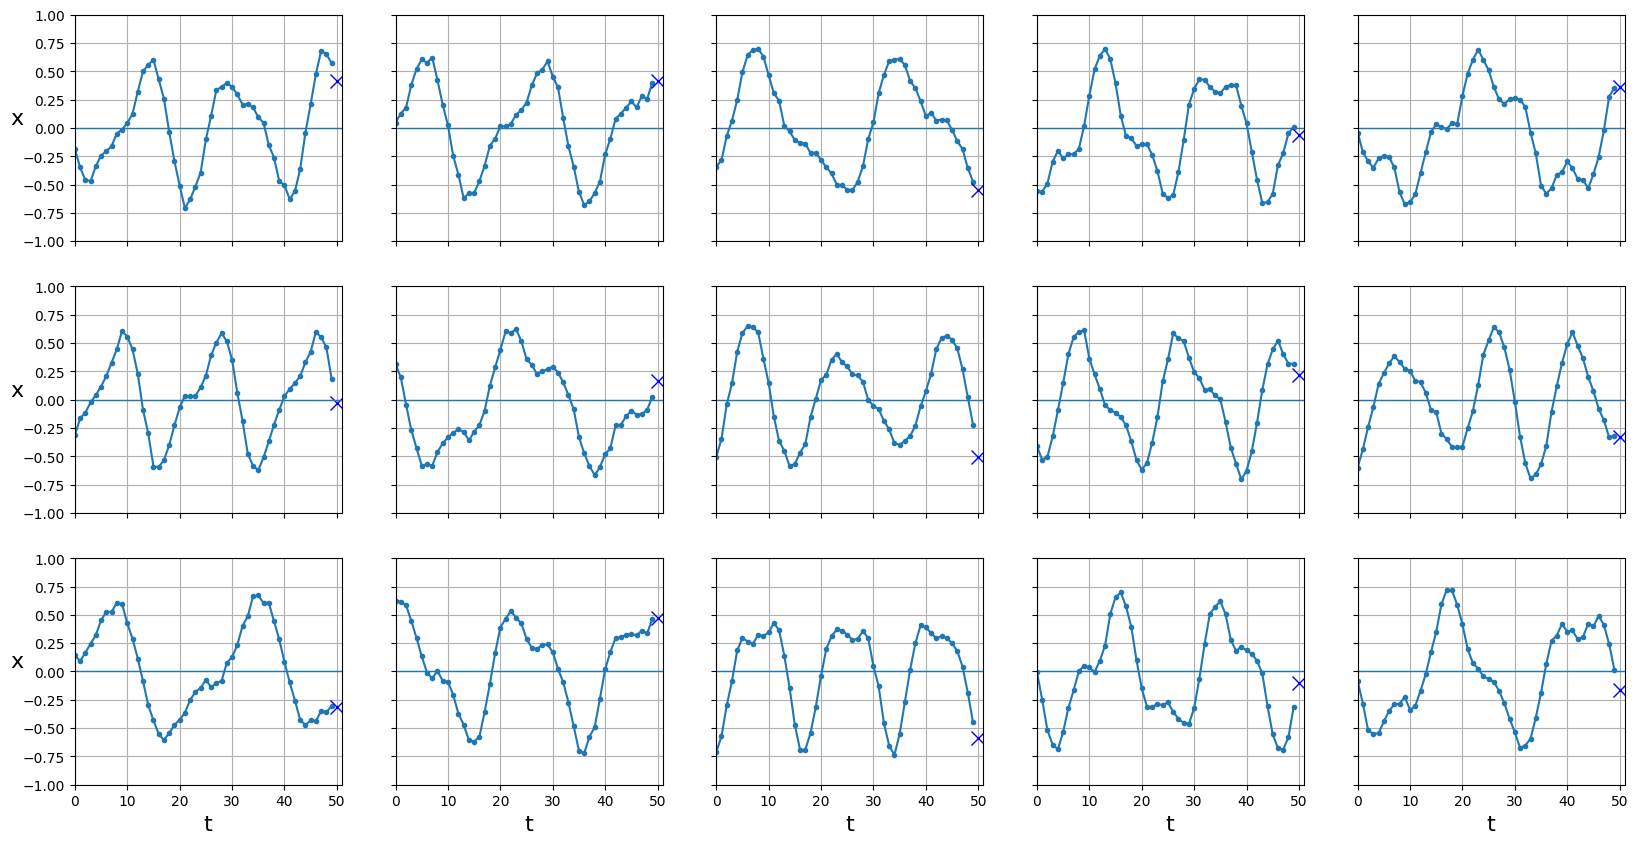

In [4]:
import matplotlib.pyplot as plt

def plot_series(series, y=None, y_pred=None, y_pred_std=None, x_label="$t$", y_label="$x$"):
  r, c = 3, 5
  fig, axes = plt.subplots(nrows=r, ncols=c, sharey=True, sharex=True, figsize=(20, 10))
  for row in range(r):
    for col in range(c):
        plt.sca(axes[row][col])
        ix = col + row*c
        plt.plot(series[ix, :], ".-")
        if y is not None:
            plt.plot(range(len(series[ix, :]), len(series[ix, :])+len(y[ix])), y[ix], "bx", markersize=10)
        if y_pred is not None:
            plt.plot(range(len(series[ix, :]), len(series[ix, :])+len(y_pred[ix])), y_pred[ix], "ro")
        if y_pred_std is not None:
            plt.plot(range(len(series[ix, :]), len(series[ix, :])+len(y_pred[ix])), y_pred[ix] + y_pred_std[ix])
            plt.plot(range(len(series[ix, :]), len(series[ix, :])+len(y_pred[ix])), y_pred[ix] - y_pred_std[ix])
        plt.grid(True)
        plt.hlines(0, 0, 100, linewidth=1)
        plt.axis([0, len(series[ix, :])+len(y[ix]), -1, 1])
        if x_label and row == r - 1:
          plt.xlabel(x_label, fontsize=16)
        if y_label and col == 0:
          plt.ylabel(y_label, fontsize=16, rotation=0)
  plt.show()

plot_series(X_test, y_test)

In [5]:
from sklearn.metrics import mean_squared_error

y_pred = X_test[:,-1]
mean_squared_error(y_test, y_pred)

0.02021130360662937

In [6]:
y_pred = X_test[:,-1]
mean_squared_error(y_test, y_pred)

0.02021130360662937

# Prediccion naive
este fue un modelo muy simple que predijo un unico valor a partir de todos los anteriroes

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y=None, train=True):
        self.X = X
        self.y = y
        self.train = train

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, ix):
        if self.train:
            return torch.from_numpy(self.X[ix]), torch.from_numpy(self.y[ix])
        return torch.from_numpy(self.X[ix])

dataset = {
    'train' : TimeSeriesDataset(X_train, y_train),
    'eval' : TimeSeriesDataset(X_valid, y_valid),
    'test' : TimeSeriesDataset(X_test, y_test, train=False)
}

dataloader = {
    'train' : DataLoader(dataset['train'],batch_size=64, shuffle=True),
    'eval' : DataLoader(dataset['eval'], batch_size=64, shuffle=False),
    'test' : DataLoader(dataset['test'], batch_size=64, shuffle=False)
}

In [ ]:
class RNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
    self.rnn = torch.nn.RNN(input_size=1, hidden_size=1, num_layers=1, batch_first= True)
    self.fc = torch.nn.Linear(20, 1)

